# Systems Report

### Systems Design

TechTrack Logistics requires a computer vision solution for autonomous warehouse robots to perceive their environment accurately. The system must detect objects, ensure human safety, prevent shipment damage, and adapt to diverse warehouse settings. Specifically, the system should atleast detect 20 significant objects from a video stream (30 frames per second.) Additionally, it should support human-in-the-loop corrections and operate on CPU-only computing resources.

The system design for TechTrack Logistics' autonomous warehouse robots consists of several key components and processes to ensure accurate perception of the environment, safety, and adaptability across diverse warehouse settings.

The video stream capture component, implemented through a UDP video stream source, captures video frames from a live feed at 30 frames per second. This live feed serves as the input for the subsequent object detection process. The object detection component utilizes a pre-trained YOLOv4-tiny object detector. This model balances speed and accuracy, making it suitable for real-time detection requirements.

Following object detection, the non-maximal suppression (NMS) module processes the detected bounding boxes to filter out overlapping boxes, keeping only the most accurate detections. This step enhances the precision of the detection results by reducing false positives.

The system also incorporates a human-in-the-loop correction component, demonstrated by Flask endpoints that help retrieve annotations and their labeled images for the user. This may allow human reviewers to manually correct detection errors, ensuring continuous improvement of the model. Corrections made by human reviewers could be fed back into the model for learning and updating, enhancing the system's accuracy over time.

Inference is performed using the inference service, which is optimized for CPU-only resources. This ensures that the system can operate without relying on GPUs, making it more accessible and cost-effective. 

The safety and damage prevention component, can be implemented through a safety module, playing a critical role in recognizing human presence and preventing robot movements that might cause harm or damage shipments. This module ensures the safety of humans sharing the workspace with the robots, as well as the integrity of customer shipments. The safety and damage prevention component, although not directly implemented, leverages the system's capability to identify and classify humans and other objects. This identification and classification allow the system to facilitate safety and damage prevention by enabling the robots to make informed decisions to avoid harm or damage.

Overall, the system is designed to meet the requirements of accurate object detection, human safety, and adaptability, with a robust feedback mechanism for continuous improvement and CPU-based inference for cost-effectiveness.

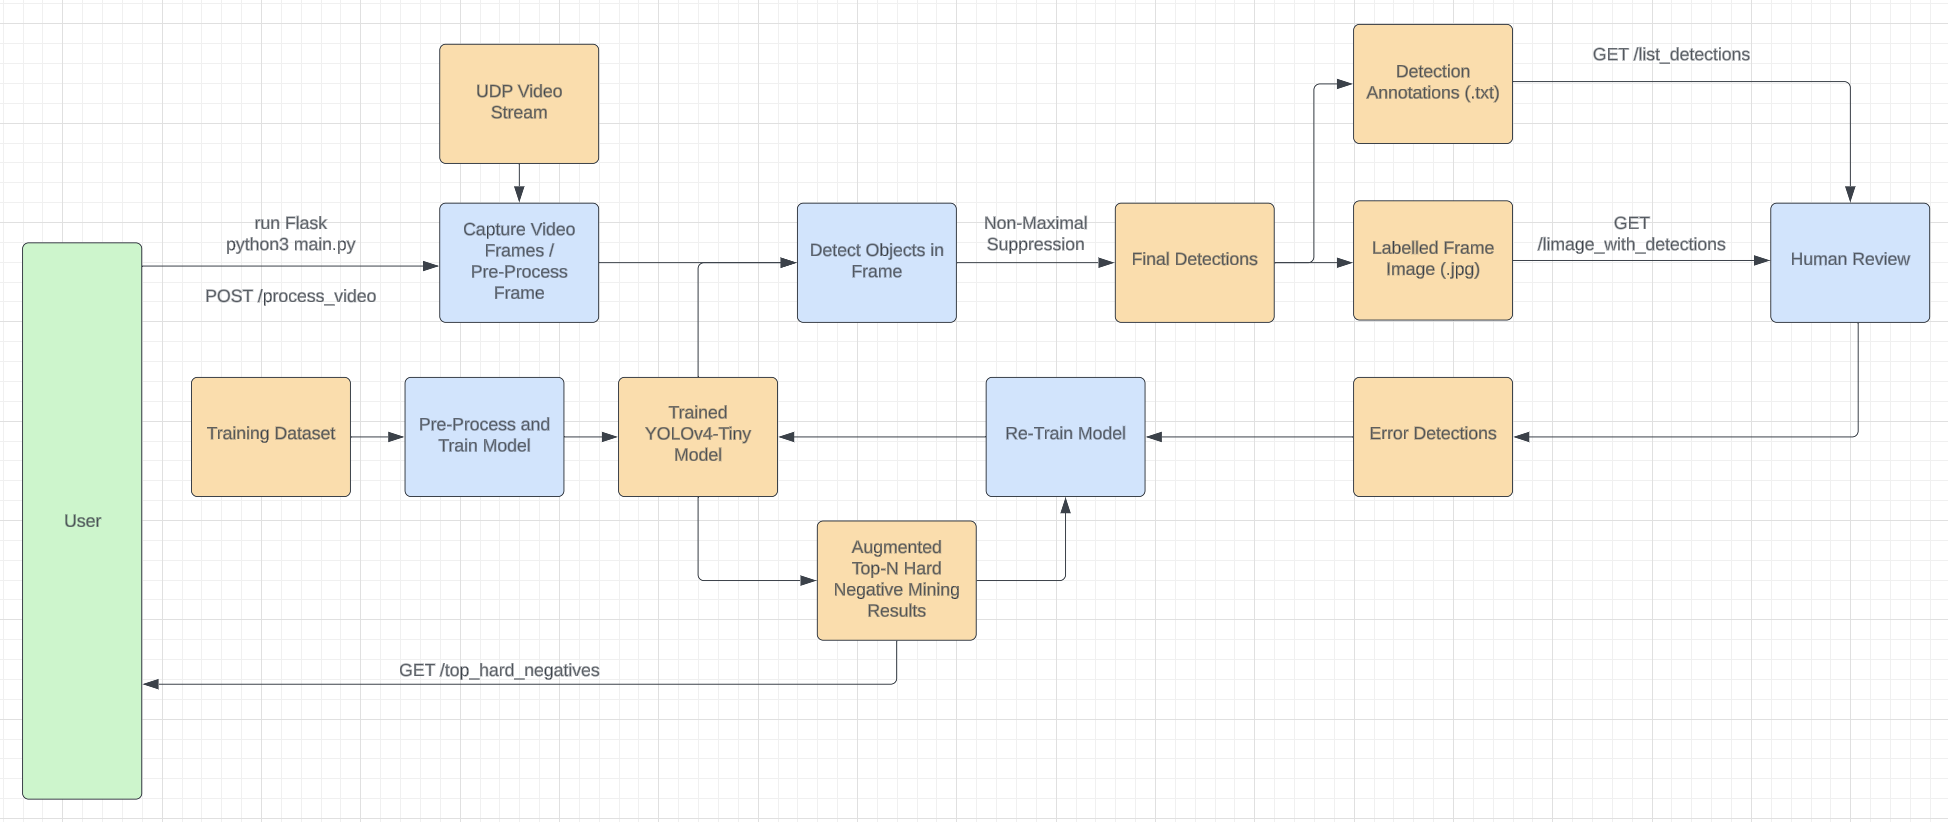

### Data, Data Pipelines and Model

#### Data

The data for this system is composed of three primary components: the training data, the input video data, and the output annotation data.

* **Training Data:** The model is trained on a zipped folder of images and their corresponding YOLO-formatted annotation files. These annotations provide the ground truth labels necessary for the model to learn how to detect objects accurately. The training dataset is crucial for developing a robust object detection model capable of performing well in real-world warehouse environments.

* **Input Video Data:** This consists of a real-time video stream captured from various warehouse environments. The video stream provides the visual input for the system, which is processed to detect objects within the warehouse. The input video data is captured at a rate of 30 frames per second from a UDP stream, ensuring that the system receives a continuous feed of visual information.

* **Output Annotation Data:** This includes the detected objects in each frame. The inference model allows for annotations in the YOLO, COCO and PASCAL formats. The annotations are saved in YOLO format, unless instructed otherwise by the user, and can be used to update the model, ensuring continuous learning and improvement. The output annotation data is essential for the human-in-the-loop correction process, enabling the system to adapt and enhance its detection capabilities over time.

#### Data Pipelines

The data pipeline for this system is designed to efficiently process the incoming video stream and generate accurate object detections.

**Data Ingestion:** Video frames are captured from the UDP stream at a rate of 30 frames per second using the VideoProcessing class. This step ensures that the system receives a steady flow of visual data from the warehouse environment. The VideoProcessing class initializes the video capture with the UDP URL and includes a mechanism to skip frames (default is to process one frame every 30 frames) to balance the processing load and real-time requirements.

**Preprocessing:** The captured frames are resized to a fixed size (e.g., 416x416 pixels) and prepared for detection. This preprocessing step, handled by the YOLOObjectDetector class, ensures that the frames are in the optimal format and size for the detection model to process efficiently.

**Detection Pipeline:** The preprocessed frames are passed through the YOLOv4-tiny model, which performs object detection. The model is to detect objects within each frame corresponding to the label groups, balancing speed and accuracy to provide real-time detection capabilities.

**Post-processing:** After the initial detection, the results are passed through the Non-Maximal Suppression (NMS) module. NMS filters out overlapping bounding boxes, retaining only the most accurate detections to reduce false positives and improve the precision of the detection results.

**Annotation and Storage:** The detected frames are labelled with the detected object bounding boxes and saved to a folder called predictions. Along with this, their annotations are saved in either the YOLO, COCO or Pascal formats (default = YOLO). The saved frame images and annotations that are saved can be reviewed and corrected by human operators. These corrections can be fed back into the system to update and improve the model, ensuring continuous learning and adaptation to different warehouse settings.

**Hard Negative Mining:** The Hard Negative Miner class identifies and augments difficult examples (hard negatives) that the model struggles with, enhancing the robustness and accuracy of the model. This process involves reading images and annotations, making predictions, computing measures, and augmenting the identified hard negatives. The augmented images of the hard negatives can be further used to re-train the model to better classify the previously mis-detected objects.

#### Model

When choosing a model for real-time object detection in warehouse environments, it's essential to consider various factors such as speed, accuracy, and resource requirements. YOLO (You Only Look Once) stands out in this regard due to its design tailored for high-speed inference. The YOLOv4-tiny variant is particularly optimized for applications that demand real-time processing, like autonomous warehouse robots. While it sacrifices some accuracy compared to more computationally intensive models, it strikes a good balance between speed and detection performance. Additionally, YOLO incorporates Non-Maximal Suppression (NMS) to filter out overlapping bounding boxes, ensuring that only the most accurate detections are retained, which enhances the overall precision of the system.

Comparatively, the Single Shot MultiBox Detector (SSD) is another contender for real-time object detection. SSD provides decent speed and better accuracy than older YOLO versions, but it typically lags slightly behind YOLOv4-tiny in terms of processing speed. SSD's architecture, which predicts bounding boxes and class scores in a single forward pass, is more complex and can be more computationally intensive, requiring more resources to achieve similar performance levels. Although SSD can run on CPU with some optimizations, it does not match the efficiency of YOLOv4-tiny in resource-constrained environments. Like YOLO, SSD also utilizes NMS to improve detection accuracy, but the overall system efficiency is still lower than that of YOLOv4-tiny.

On the other hand, Faster R-CNN is renowned for its high accuracy in object detection, thanks to its two-stage detection process involving a region proposal network followed by a classification network. However, this high accuracy comes at the cost of processing speed, making Faster R-CNN unsuitable for real-time applications. The computational intensity of Faster R-CNN typically necessitates GPU support, which contradicts the system requirement of operating on CPU-only resources. Therefore, despite its superior accuracy, Faster R-CNN is not a viable option for real-time, resource-efficient applications in dynamic environments like warehouses. Due to the algorithm's complex architecture, integration of hard negative mining techniques, which are crucial for improving model robustness, is difficult to do.

Given the specific needs of TechTrack Logistics, YOLOv4-tiny was selected for its superior balance of speed and accuracy. Its real-time processing capability ensures that video streams can be handled at 30 frames per second, meeting the critical requirement for timely detection and response. Moreover, YOLOv4-tiny's ability to operate efficiently on CPU-only systems aligns with the project's resource constraints, providing a cost-effective and practical solution. The model's simplicity and proven effectiveness in similar applications further reinforce its suitability, making YOLOv4-tiny the optimal choice for enhancing the safety and efficiency of TechTrack's autonomous warehouse robots. Additionally, the integration of a Hard Negative Miner within the system allows for continuous model improvement by identifying and augmenting difficult examples, thereby enhancing detection accuracy and robustness over time.

### Metrics

#### Offline Metrics

* **Total Loss:** Total loss is chosen as a comprehensive metric during the model training phase because it encapsulates multiple aspects of the model's performance, including localization, confidence, and classification. By monitoring the total loss, we can ensure that the model is learning effectively and improving its predictions. A decrease in total loss over time indicates that the model is becoming better at matching its predictions with the ground truth annotations.

* **Localization Loss (loc_loss)**: Localization loss measures how accurately the predicted bounding box coordinates match the ground truth. This loss is weighted by a factor (lambda_coord) and is essential for ensuring that the predicted boxes are well-positioned and sized accurately. By using an IoU threshold, this metric ensures that only predictions with significant overlap with the ground truth are considered, thereby improving the precision of object detection in the system.

* **Confidence Loss (conf_loss_obj and conf_loss_noobj)**: Confidence loss includes object confidence loss (conf_loss_obj) and no object confidence loss (conf_loss_noobj). The object confidence loss evaluates the difference between the predicted objectness score and the ground truth for cells containing objects, encouraging the model to be confident about true detections. The no object confidence loss penalizes high confidence scores in cells without objects, reducing false positives. These losses are weighted by lambda_noobj and help the model effectively distinguish between object and background regions. The IoU threshold ensures that confidence scores are calculated based on high-quality bounding boxes, reducing the likelihood of false detections.

* **Classification Loss (class_loss)**: Classification loss measures the accuracy of the predicted class probabilities against the ground truth class labels using cross-entropy loss. This metric is vital for ensuring that the model correctly identifies different objects within the warehouse environment. By focusing on accurate classification, the model can provide reliable information about the types of objects detected, which is crucial for operational decisions. The IoU threshold used in calculating classification loss ensures that only well-localized predictions contribute to the class accuracy.

#### Online Metrics

* **Precision:** Precision is the ratio of true positive detections to the total number of detections (true positives + false positives). It measures the accuracy of positive predictions made by the model. High precision is crucial for this system to ensure a low false positive rate, which reduces errors in object detection and enhances the system's reliability in real-time operations. The IoU threshold ensures that only predictions with significant overlap with the ground truth are considered true positives, improving the quality of detections.

* **Recall:** Recall is the ratio of true positive detections to the total number of actual positives (true positives + false negatives). It measures the model's ability to identify all relevant objects within the frame. High recall is essential for capturing most objects in the warehouse environment, ensuring operational efficiency and safety. The IoU threshold ensures that only high-quality detections are considered, thereby improving the model's coverage of true objects.

* **F1 Score:** The F1 score is the harmonic mean of precision and recall, providing a single metric that balances both. It is particularly useful when there is an uneven class distribution or when false positives and false negatives have different costs. A high F1 score indicates a good balance between precision and recall, making it a comprehensive metric for evaluating the model's performance. The IoU threshold ensures that both precision and recall are calculated based on high-quality detections.

* **Frame Processing Time:** Frame processing time measures the time taken to process each frame from the video stream, including all stages of object detection and post-processing. This metric is crucial for ensuring that the system operates in real-time, processing 30 frames per second as required. Low frame processing time indicates efficient model and system performance, essential for real-time applications.

* **Detection Latency:** Detection latency is the end-to-end time from capturing a frame to producing the detection output. It encompasses data ingestion, preprocessing, model inference, and post-processing stages. Minimizing detection latency is critical for real-time applications where timely detection and response are necessary for operational efficiency and safety.

* **System Throughput:** System throughput measures the number of frames processed per second. It is a direct indicator of the system's ability to handle the required video feed rate. High system throughput ensures that the system can keep up with the live video stream without lag, maintaining real-time performance.

These offline and online metrics collectively provide a comprehensive evaluation framework for the object detection system, ensuring that it meets the performance, accuracy, and real-time requirements necessary for effective deployment in warehouse environments.

### Post-Deployment Policies

#### Monitoring and Maintenance Plan

Regular maintenance involves scheduling updates for system components, including the object detection model, dependencies, and underlying libraries, during designated maintenance windows to minimize downtime. Periodically retraining the object detection model with new data from the warehouse environment ensures it adapts and maintains accuracy. Implementing regular data backup procedures to securely back up input video data, annotated images, and system logs, utilizing automated solutions and storing backups in multiple locations will prevent data loss.

For real-time monitoring, we can implement tools like Prometheus to track system performance metrics, including CPU usage, memory usage, and disk I/O, visualizing them in real-time. Continuously monitor the object detection model's performance by logging and analyzing precision, recall, F1 score, and detection latency for each frame processed. Additionally, set up an alerting system with tools like Nagios to notify responsible personnel when critical thresholds such as high CPU usage, memory leaks, or significant drops in model performance are reached. This is crucial to prevent any incidents that may occur with the robot in the warehouse. 

Performance audits involve conducting periodic evaluations of the system's efficiency and accuracy by analyzing logs and metrics to identify areas for improvement and make necessary adjustments. Gathering feedback from warehouse operators and other users, who often interact with the robot, can pinpoint issues and areas for enhancement. This feedback can be used to inform maintenance activities and guide system enhancements.

#### Fault Mitigation Strategies

Implementing redundant systems by deploying multiple instances of the object detection system ensures fault tolerance by allowing other instances to take over if one fails. Setting failover mechanisms to trigger the switch to backup systems automatically when the primary system fails prevents any downtime in the operation. Error handling mechanisms deployed while creating the system can be used to log errors and provide useful error messages to troubleshoot any complications that arise. Monitoring of performance metrics can help in identifying model drift, allowing for re-training before detrimental performance changes occur. It is also crucial to document the development and post-development process for review. Doing so will allow easy system maintenance and auditing.